# Lecture 9 — Robust Portfolio Construction
## Risk parity, risk budgeting, and worst-case optimisation

This companion notebook reworks the old PyPortfolioOpt / Riskfolio-Lib robust-optimisation
walk-through using the **GAA framework** (`optimization/`, `risk_models/`). No external
portfolio library or Google-Drive data is required. It illustrates:

1. Summary statistics of a multi-asset universe
2. **Risk contributions** — why equal *capital* weights do not give equal *risk*
3. **Risk parity** — equalising risk contributions (`optimization.risk_budget`)
4. 1/N vs risk parity **over time** (driven through the `Backtester`)
5. **Robust optimisation** — worst-case mean-variance with elliptical uncertainty sets for
   both μ and Σ (`optimization.robust`)
6. A three-way comparison: classic mean-variance vs robust vs risk parity

Data: monthly indexed performance from `perf_M.parquet`
(generated by `data/run_pipes.py`). Columns ending in `-r` are simple monthly returns; `-i`
are price levels.

Code: `optimization.risk_budget`, `optimization.robust`, `optimization.mean_risk`,
`risk_models.risk_analytics`, `risk_models.covariance` — see
`saa/examples/run_risk_budget_backtest_example.py` and
`saa/examples/run_robust_optimization_example.py` for the runnable scripts this notebook distils.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analytics.timeseries_analyzer import TimeseriesAnalyzer
from backtesting import BacktestConfig, Backtester
from risk_models.covariance import compute_covariance, compute_rolling_covariance
from risk_models.risk_analytics import (
    marginal_risk_contributions,
    risk_contributions,
    fig_risk_contribution_bars,
    fig_comparison_over_time,
)
from optimization.risk_budget import RiskBudgetOptimizer
from optimization.mean_risk import MeanRiskOptimizer
from optimization.objectives import MaxUtility
from optimization.risk_measures import Variance
from optimization.robust import RobustMeanVarianceOptimizer, worst_case_stats

DATA_PATH = REPO_ROOT / "perf_M.parquet"
ANN = 12  # months per year

pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load market data and summary statistics

We use a broad multi-asset universe spanning cash, rates, inflation-linked and credit, equities,
gold, real estate, and commodities. From the monthly returns we compute the annualised average
return, annualised compound (geometric) return, annualised volatility, and the return/risk
ratio.

In [2]:
UNIVERSE = {
    "MM_US_USD": "Money market",
    "FI_HY_US": "High Yield",
    "FI_IL_US": "U.S. TIPS",
    "FI_GB_US": "U.S. Treasuries",
    "FI_IG_US": "IG Bonds",
    "EQ_EA": "Equities ex-US",
    "EQ_EM": "EM Equities",
    "GOLD": "Gold",
    "EQ_RE": "Real Estate",
    "EQ_US": "S&P 500",
    "CO": "Commodities",
}

perf = pd.read_parquet(DATA_PATH)
df = perf[[f"{t}-r" for t in UNIVERSE]].dropna()
df.columns = [UNIVERSE[c[:-2]] for c in df.columns]

print(f"Period: {df.index[0].date()} -> {df.index[-1].date()}  ({len(df)} months)")

summary = pd.DataFrame({
    "Ann. mean": df.mean() * ANN,
    "Ann. compound": (1 + df).prod() ** (ANN / len(df)) - 1,
    "Ann. vol": df.std() * np.sqrt(ANN),
})
summary["Return/Risk"] = summary["Ann. mean"] / summary["Ann. vol"]
summary

Period: 2006-05-31 -> 2025-12-31  (236 months)


,Ann. mean,Ann. compound,Ann. vol,Return/Risk
Money market,0.0219,0.0221,0.0062,3.5150
High Yield,0.0690,0.0667,0.0915,0.7547
U.S. TIPS,0.0382,0.0371,0.0583,0.6552
U.S. Treasuries,0.0296,0.0289,0.0457,0.6480
IG Bonds,0.0455,0.0443,0.0650,0.6999
Equities ex-US,0.0674,0.0545,0.1677,0.4017
EM Equities,0.0742,0.0546,0.2032,0.3652
Gold,0.1101,0.1007,0.1669,0.6600
Real Estate,0.0585,0.0396,0.1943,0.3011
S&P 500,0.1159,0.1092,0.1536,0.7550


## 2. Risk contributions and the 1/N portfolio

For a portfolio with weights $w$ and covariance $\Sigma$, the volatility is
$\sigma_p=\sqrt{w^\top\Sigma w}$. By Euler's theorem it decomposes into additive
**risk contributions**:

$$\sigma_p = \sum_i w_i\,\underbrace{\frac{(\Sigma w)_i}{\sqrt{w^\top\Sigma w}}}_{\text{MRC}_i}
= \sum_i \text{CTR}_i .$$

`risk_models.risk_analytics.risk_contributions` returns the $\text{CTR}_i$ (absolute, summing to
$\sigma_p$) or their relative shares (summing to 1). For the **equal-weight (1/N)** portfolio the
risk contributions are very *un*-equal: the high-volatility equity indices dominate, while
money-market and government bonds barely register.

Portfolio volatility (1/N): 0.0880


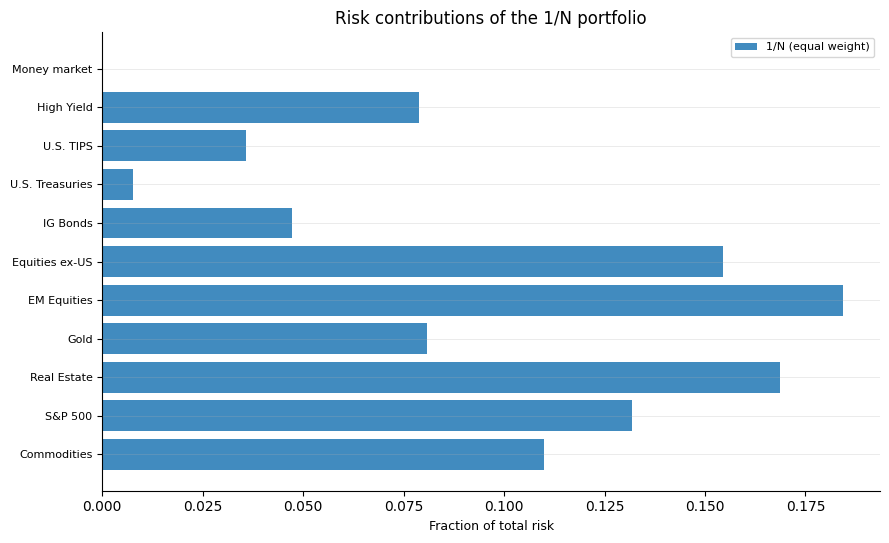

,Marginal RC,Risk share
EM Equities,0.1785,0.1843
Real Estate,0.1635,0.1688
Equities ex-US,0.1496,0.1545
S&P 500,0.1277,0.1318
Commodities,0.1065,0.1100
Gold,0.0782,0.0807
High Yield,0.0764,0.0788
IG Bonds,0.0458,0.0473
U.S. TIPS,0.0347,0.0359
U.S. Treasuries,0.0075,0.0077


In [3]:
cov_full = compute_covariance(df, method="sample") * ANN          # annualised
w_eq = pd.Series(1.0 / len(df.columns), index=df.columns)

mrc = marginal_risk_contributions(w_eq, cov_full)
ctr = risk_contributions(w_eq, cov_full, relative=True)
print("Portfolio volatility (1/N): "
      f"{np.sqrt(w_eq.values @ cov_full.values @ w_eq.values):.4f}")

fig = fig_risk_contribution_bars({"1/N (equal weight)": w_eq}, cov_full, relative=True)
fig.axes[0].set_title("Risk contributions of the 1/N portfolio")
plt.show()

pd.DataFrame({"Marginal RC": mrc, "Risk share": ctr}).sort_values("Risk share", ascending=False)

Equity indices each contribute 15-20 % of total risk while money market contributes almost
nothing — equal *capital* weighting silently concentrates *risk* in equities.

## 3. Risk parity

**Risk parity** chooses weights so that every asset contributes the *same* share of risk
($\text{CTR}_i = 1/N$). GAA solves the Spinu (2013) log-barrier risk-budgeting problem in
`RiskBudgetOptimizer`.

We **drop money market** here: with near-zero volatility it would receive an enormous
risk-parity weight ($w_i\propto\sqrt{b_i/\Sigma_{ii}}$), swamping the portfolio — the same
reason the original notebook worked with `df_exMM`.

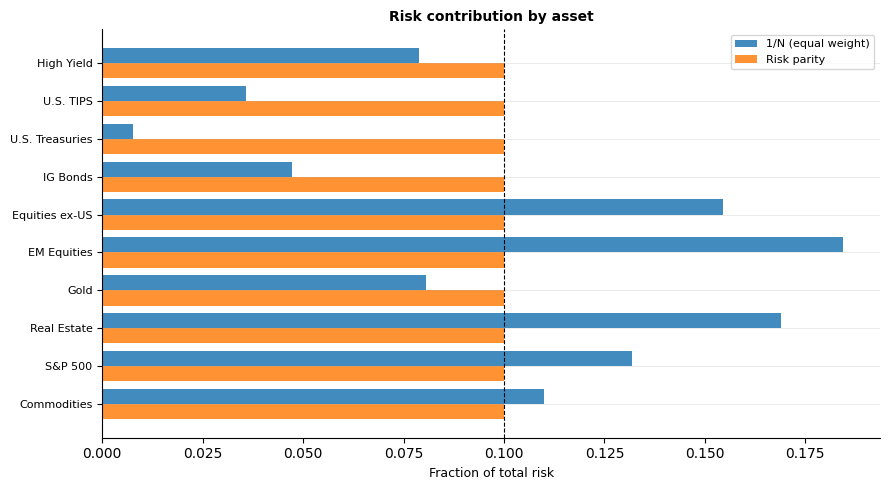

,1/N weight,1/N risk %,RP weight,RP risk %
High Yield,0.1000,0.0789,0.0899,0.1000
U.S. TIPS,0.1000,0.0358,0.1416,0.1000
U.S. Treasuries,0.1000,0.0077,0.3271,0.1000
IG Bonds,0.1000,0.0473,0.1175,0.1000
Equities ex-US,0.1000,0.1545,0.0482,0.1000
EM Equities,0.1000,0.1844,0.0402,0.1000
Gold,0.1000,0.0806,0.0684,0.1000
Real Estate,0.1000,0.1689,0.0414,0.1000
S&P 500,0.1000,0.1319,0.0572,0.1000
Commodities,0.1000,0.1100,0.0684,0.1000


In [4]:
df_opt = df.drop(columns=["Money market"])
cov_opt = compute_covariance(df_opt, method="sample") * ANN
n_opt = len(df_opt.columns)

w_rp = RiskBudgetOptimizer(solver="scipy").optimize(cov_opt)
w_eq_opt = pd.Series(1.0 / n_opt, index=df_opt.columns)

# Compare risk contributions: 1/N concentrates, risk parity equalises to 1/N
fig = fig_risk_contribution_bars(
    {"1/N (equal weight)": w_eq_opt, "Risk parity": w_rp}, cov_opt, relative=True
)
fig.axes[0].axvline(1.0 / n_opt, color="black", lw=0.8, ls="--")
plt.show()

pd.DataFrame({
    "1/N weight": w_eq_opt,
    "1/N risk %": risk_contributions(w_eq_opt, cov_opt, relative=True),
    "RP weight": w_rp,
    "RP risk %": risk_contributions(w_rp, cov_opt, relative=True),
}).round(4)

Risk parity tilts *capital* toward the low-volatility assets (Treasuries, TIPS) so that every
asset's *risk* share is exactly $1/N$.

## 4. 1/N vs risk parity over time

A single in-sample snapshot hides how the two portfolios behave through changing markets. We drive
both through the GAA `Backtester` with **annual rebalancing** and an **EWMA covariance** (36-month
half-life) for risk parity, then compare NAV, weights, and risk contributions month by month.
Between rebalances the weights drift, so risk-parity contributions fan out from $1/N$ and snap back
at each rebalance.

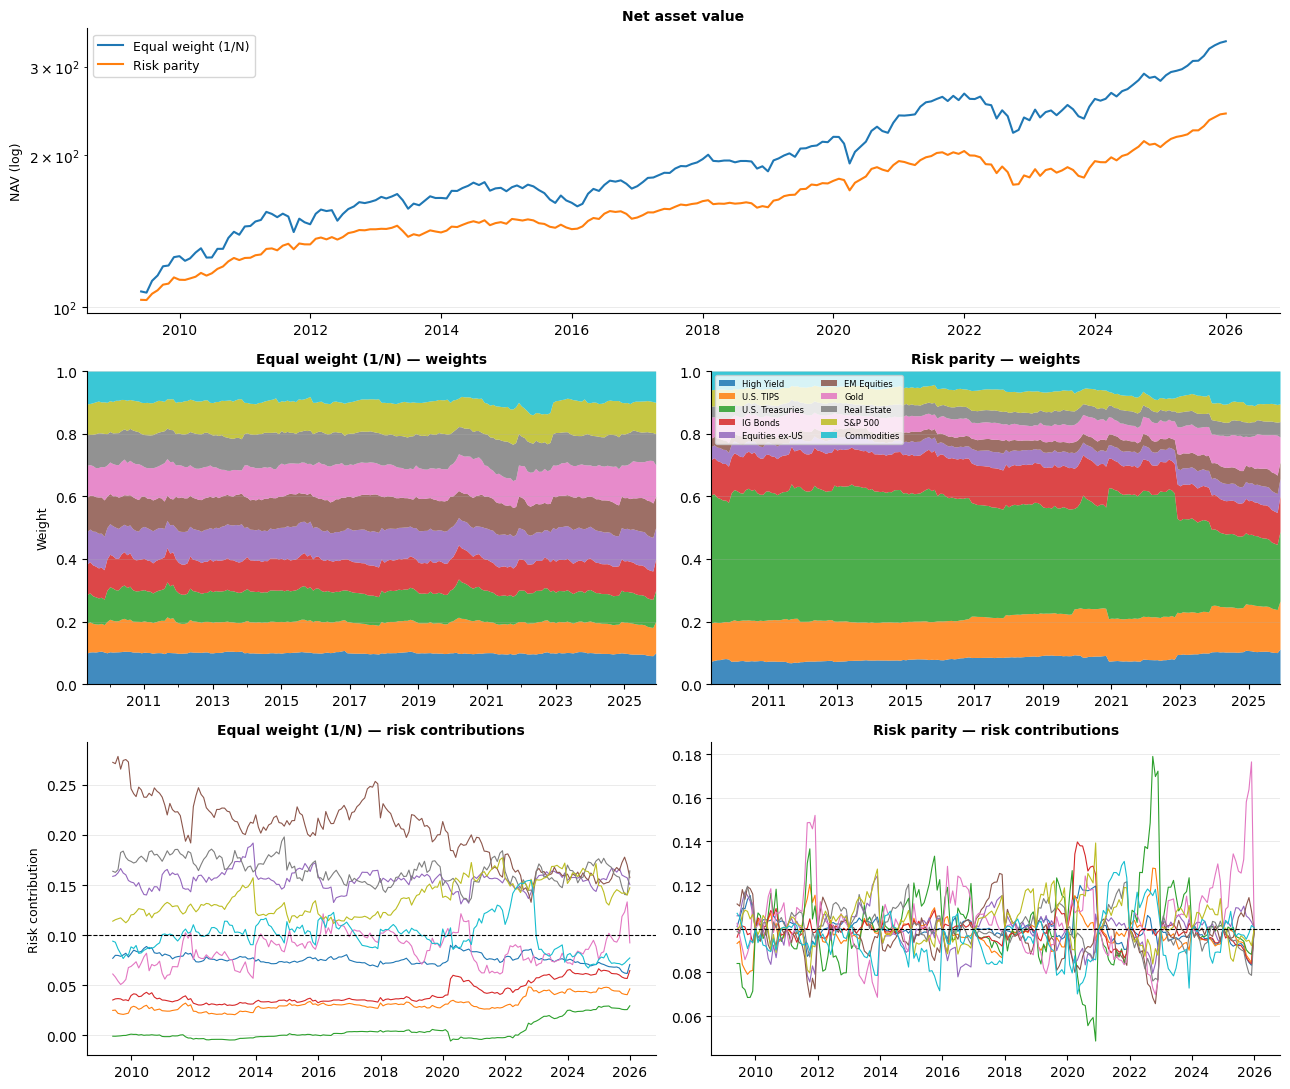

,Equal weight (1/N),Risk parity
calc_cagr,0.0713,0.0527
calc_arithmetic_mean_return,0.0726,0.0529
calc_volatility,0.0842,0.0537
calc_sharpe_ratio,0.8628,0.9847
calc_sharpe_ratio_rf0,0.8628,0.9847
calc_sortino_ratio,0.8321,0.9934
calc_max_drawdown__max_drawdown,-0.1640,-0.1425
calc_max_drawdown__peak_date,2021-12-31 00:00:00,2021-12-31 00:00:00
calc_max_drawdown__trough_date,2022-09-30 00:00:00,2022-09-30 00:00:00
calc_max_drawdown__recovery_date,2024-03-31 00:00:00,2024-07-31 00:00:00


In [5]:
OPT = [t for t in UNIVERSE if t != "MM_US_USD"]
names = [UNIVERSE[t] for t in OPT]
prices = perf[[f"{t}-i" for t in OPT]].dropna()
rets = perf[[f"{t}-r" for t in OPT]].dropna()
rets.columns = names
price_cols = list(prices.columns)


class RiskParityStrategy:
    def __init__(self, returns):
        self.snaps = compute_rolling_covariance(
            returns, freq="ME", method="ewma", halflife=36, annualize=True
        )
        self.dates = sorted(self.snaps)
        self.opt = RiskBudgetOptimizer(solver="scipy", transaction_cost_bps=10)

    def nearest(self, as_of):
        valid = [d for d in self.dates if d <= as_of]
        return self.snaps[valid[-1] if valid else self.dates[0]]

    def compute_weights(self, data, as_of, current_weights):
        cur = None
        if current_weights is not None:
            cur = pd.Series(current_weights.values, index=names)
        w = self.opt.optimize(self.nearest(as_of), current_weights=cur)
        return pd.Series(w.values, index=price_cols)


class EqualWeightStrategy:
    def compute_weights(self, data, as_of, current_weights):
        return pd.Series(1.0 / len(price_cols), index=price_cols)


config = BacktestConfig(
    initial_capital=100.0, transaction_cost_bps=10,
    rebalance_freq="YE", initial_weights_from_strategy=True,
)
burn_in = prices.index[0] + pd.DateOffset(years=3)
prices_bt = prices.loc[burn_in:]

rp = RiskParityStrategy(rets)
bt = Backtester(config)
results = {
    "Equal weight (1/N)": bt.run(prices_bt, strategy=EqualWeightStrategy()),
    "Risk parity": bt.run(prices_bt, strategy=rp),
}

navs, weights_by, rc_by = {}, {}, {}
for label, r in results.items():
    wdf = r.weights_history.copy()
    wdf.columns = names
    navs[label] = r.nav
    weights_by[label] = wdf
    rc_by[label] = pd.DataFrame(
        {dt: RiskBudgetOptimizer.risk_contributions(wdf.loc[dt], rp.nearest(dt))
         for dt in wdf.index}
    ).T

fig = fig_comparison_over_time(navs, weights_by, rc_by)
plt.show()

TimeseriesAnalyzer(pd.DataFrame(navs)).apply_standard_functions()

## 5. Robust optimisation: worst-case mean-variance

Classic mean-variance takes the estimates $(\hat\mu,\hat\Sigma)$ at face value and over-fits
estimation noise. **Robust optimisation** instead treats them as centres of *uncertainty sets* and
hedges against the worst case inside them.

We use **elliptical** sets for both inputs (the GAA analogue of Riskfolio's
`Umu='ellip', Ucov='ellip'`):

- mean ellipsoid $U_\mu=\{\mu:(\mu-\hat\mu)^\top\Sigma_\mu^{-1}(\mu-\hat\mu)\le k_\mu^2\}$
  $\Rightarrow$ worst-case return $\hat\mu^\top w-k_\mu\lVert\Sigma_\mu^{1/2}w\rVert_2$;
- covariance ellipsoid $\Rightarrow$ worst-case variance, made tractable by the lift
  $W\succeq ww^\top$ (a small semidefinite program).

`worst_case_stats` estimates the set parameters under normality
($\Sigma_\mu=\hat\Sigma/T$, $\chi^2$ radii). We solve the robust **max-utility** problem.

> Note: we use the *max-utility* objective (not the notebook's original max-Sharpe). Robust
> max-Sharpe is a fractional program that does not compose with the semidefinite lift, so we keep a
> single shared objective across all three portfolios below.

In [6]:
LAMBDA = 5.0
stats = worst_case_stats(df_opt, q=0.05)
print(f"Uncertainty radii:  k_mu = {stats.k_mu:.2f}   k_sigma = {stats.k_sigma:.2f}")

w_robust = RobustMeanVarianceOptimizer().optimize(
    stats, objective="max_utility", risk_aversion=LAMBDA
)
pd.DataFrame({
    "Robust weight": w_robust,
    "Robust risk %": risk_contributions(w_robust, stats.cov, relative=True),
}).round(4)

Uncertainty radii:  k_mu = 4.28   k_sigma = 8.56


,Robust weight,Robust risk %
High Yield,0.2184,0.2030
U.S. TIPS,0.0000,0.0000
U.S. Treasuries,0.3019,0.0594
IG Bonds,0.0000,0.0000
Equities ex-US,0.0000,0.0000
EM Equities,0.0000,0.0000
Gold,0.2228,0.3306
Real Estate,0.0000,0.0000
S&P 500,0.2569,0.4071
Commodities,0.0000,0.0000


## 6. Three-way comparison: mean-variance vs robust vs risk parity

Finally we put the three philosophies side by side on the same inputs:

- **Mean-variance** maximises $\hat\mu^\top w-\tfrac{\lambda}{2}w^\top\hat\Sigma w$;
- **Robust** does the same but worst-case over the uncertainty sets;
- **Risk parity** ignores $\hat\mu$ entirely and equalises risk.

Robust optimisation trims a little expected return but **lowers volatility and improves the
worst-case-adjusted return/risk ratio** versus plain mean-variance; risk parity is the most
diversified (highest effective number of assets). Read these off the summary table below — the
robust portfolio need not hold more names, it holds a *better-hedged* mix.

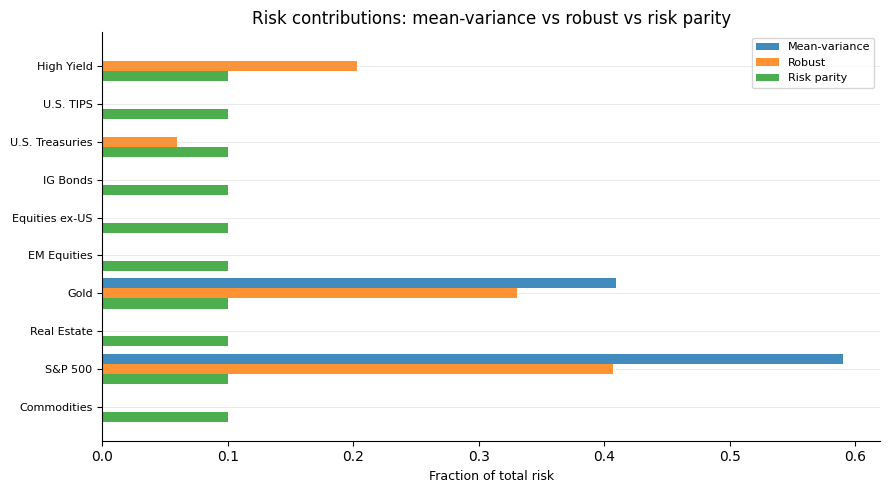

,Exp. return,Volatility,Return/Risk,Max weight,Eff. N assets
Mean-variance,0.1134,0.1176,0.9648,0.5696,1.9620
Robust,0.0783,0.0741,1.0577,0.3019,3.9297
Risk parity,0.0498,0.0634,0.7858,0.3271,5.9796


In [7]:
w_mv = MeanRiskOptimizer(solver="cvxpy").optimize(
    stats.mu, stats.cov, MaxUtility(Variance(), risk_aversion=LAMBDA)
)
w_rp_full = RiskBudgetOptimizer(solver="cvxpy").optimize(stats.cov)
portfolios = {"Mean-variance": w_mv, "Robust": w_robust, "Risk parity": w_rp_full}

fig = fig_risk_contribution_bars(portfolios, stats.cov, relative=True)
fig.axes[0].set_title("Risk contributions: mean-variance vs robust vs risk parity")
plt.show()


def describe(w):
    w_arr = w.values
    mu_dec = stats.mu.reindex(stats.cov.columns).values / 100.0
    exp_ret = float(w_arr @ mu_dec)
    vol = float(np.sqrt(w_arr @ stats.cov.values @ w_arr))
    return {
        "Exp. return": exp_ret,
        "Volatility": vol,
        "Return/Risk": exp_ret / vol,
        "Max weight": float(w.max()),
        "Eff. N assets": 1.0 / float((w_arr ** 2).sum()),
    }

pd.DataFrame({label: describe(w) for label, w in portfolios.items()}).T.round(4)

## Key takeaways

- Equal **capital** weights (1/N) do **not** give equal **risk** contributions — equities dominate
  portfolio risk.
- **Risk parity** equalises risk contributions by tilting capital toward low-volatility assets;
  over time its risk shares hug $1/N$ and drift only between rebalances.
- **Mean-variance** chases the point estimate $(\hat\mu,\hat\Sigma)$ and produces concentrated,
  estimation-error-sensitive portfolios.
- **Robust** optimisation hedges against elliptical uncertainty in both $\mu$ and $\Sigma$,
  trading a little expected return for lower volatility and a better worst-case-adjusted
  return/risk ratio — a principled middle ground between mean-variance and risk parity.
- All three are driven through the *same* GAA `optimization` API and the *same* `Backtester`, so
  swapping objectives is a one-line change.